In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
from google.cloud import bigquery
import datetime

In [64]:
people_query = """

with graduated_members as (
SELECT a. member_id FROM 
  (
    SELECT member_id FROM `dw.member_status` 
    WHERE stage_name in ('Out of Program', 'Independence')
    GROUP BY ALL
  ) a inner join (
    SELECT member_id FROM `dw.member_status` 
    WHERE stage_name in ( 'Support', 'In Program', 'Skill Building' )
    GROUP BY ALL
  ) b on a.member_id = b.member_id
  GROUP BY ALL
), 

member_start_dates as (
  select member_id, min(status_begin_date) start_date
  FROM `dw.member_status` right join graduated_members using(member_id)
  group by member_id
), 
analysis_set as (
  select member_id, start_date
  from member_start_dates
  where start_date between '2024-01-01' and '2024-12-31'
  GROUP BY ALL
)

SELECT member_id, stage_name, status_name, status_begin_time, status_end_time, client, is_graduated
FROM `dw.member_status` right join analysis_set using(member_id)
"""

bq_client = bigquery.Client(project='production-329012')
df = bq_client.query(people_query).to_dataframe()

/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
df_people = df.copy()

df_people = df_people.assign(
    stage_name = df_people.stage_name.where(~df_people.stage_name.isin(['In Program', 'Support', 'Skill Building']), 'Active With Guide')
)

df_people.status_begin_time = pd.to_datetime(df_people.status_begin_time)
df_people = df_people.assign(
    reverse_state_order = df_people.groupby(['member_id', 'client']).status_begin_time.rank(method = 'dense', ascending = False)
)

terminal_states = df_people.loc[df_people.reverse_state_order == 1.]

# get rid of members who had status updates after Independence. Not useful in this analysis. 
terminal_states = terminal_states.loc[terminal_states.stage_name.isin(['Out of Program', 'Independence'])][['member_id', 'client', 'status_name']].rename(columns = {'status_name': 'terminal_state' })

df_people = df_people.merge(
    terminal_states, 
    on =[ 'member_id', 'client']
)

sankey = df_people.drop_duplicates(subset = ['member_id', 'stage_name', 'terminal_state'])

# state_trans = df_people.groupby(['member_id', 'stage_name', 'client']).agg(
#     state_begin_date = ('status_begin_date', 'min')
# ).reset_index().sort_values(['member_id', 'state_begin_date'])

# transitions = state_trans.merge(state_trans, on = ['member_id', 'client'], )
# transitions = transitions.loc[(transitions.stage_name_x != transitions.stage_name_y) & 
#                               (transitions.state_begin_date_x <= transitions.state_begin_date_y)]


In [72]:
active_to_terminal = sankey.loc[sankey.stage_name == 'Active With Guide'][['member_id', 'stage_name', 'terminal_state']].drop_duplicates()
active_to_terminal = active_to_terminal.drop_duplicates(subset= ['member_id'])

outcome_data = active_to_terminal.groupby(['stage_name', 'terminal_state']).nunique().reset_index()



In [73]:
import plotly.express as px

fig = px.pie(outcome_data, values='member_id', names='terminal_state', title='Outcome Breakdown')
fig.show()


In [74]:
# remove outcomes that would bias the model because they are unpredictable

active_to_terminal = active_to_terminal.loc[~active_to_terminal.terminal_state.isin(['Off Plan', 'Deceased', 'Misconduct'])]
outcome_data_fixed = active_to_terminal.groupby(['stage_name', 'terminal_state']).nunique().reset_index()

fig = px.pie(outcome_data_fixed, values='member_id', names='terminal_state', title='Fixed Outcome Breakdown')
fig.show()

In [75]:
sankey = df_people.merge(active_to_terminal[['member_id']], on = 'member_id', how = 'right')

client_data = sankey.groupby(['client']).member_id.nunique().reset_index()

fig = px.pie(client_data, values='member_id', names='client', title='Client Breakdown')
fig.show()

In [76]:
active_to_terminal

,member_id,stage_name,terminal_state
1573,ae7955b0-314f-460f-8ad9-97b4f34ab878,Active With Guide,Refused Services
1575,afd3e063-29b2-44f3-b041-42801b659360,Active With Guide,Completed
1576,b3af8ca2-00b3-42f2-93f0-fd16ade16be1,Active With Guide,Unable to Re-Engage
1586,b4bf25d6-eca7-4104-9483-f39588bf6115,Active With Guide,Completed
1589,3eeb1857-e8aa-4ef3-a1f8-304face85846,Active With Guide,Completed
...,...,...,...
16887,2bf44f4b-d39c-4aae-8aa8-9b01b7813186,Active With Guide,Refused Services
18229,52dd2d47-17ac-427c-a916-84ebabaa93fa,Active With Guide,Completed
20775,5e49ea33-c989-4400-857f-d79b7b001d51,Active With Guide,Completed
25969,d91f2ee3-fee6-4c87-96e6-9ef0ec817904,Active With Guide,Refused Services


In [ ]:
ts_query = """
    SELECT  file_client_id, file_dt, count(distinct member_id) FROM 
    (SELECT member_id, file_client_id, file_dt, table_name, 
    ROW_NUMBER() OVER(partition by member_id, file_client_id order by file_dt asc) enter_field
    FROM `production-329012.dw_staging.eligibility_canon_member`) a
    WHERE a. enter_field = 1
    GROUP BY file_client_id, file_dt
    ORDER BY file_client_id, file_dt
"""
bq_client = bigquery.Client(project='production-329012')
ts = bq_client.query(ts_query).to_dataframe()


/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<Axes: xlabel='file_dt', ylabel='f0_'>

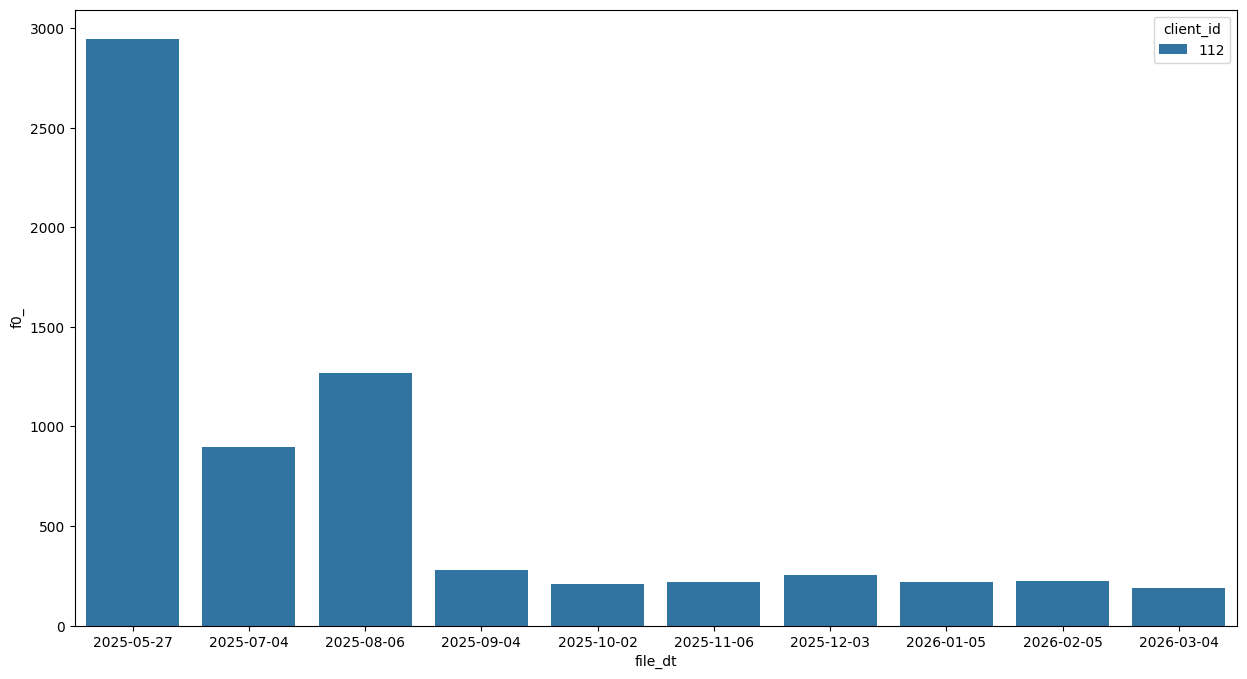

In [53]:
ts = ts.assign(
    client_id = ts.file_client_id.astype(str)
)

fig, ax = plt.subplots(figsize = (15, 8))
sns.barplot(ts.loc[ts.client_id == '112'], x = 'file_dt', y = 'f0_', hue = 'client_id')

In [44]:
ts

,file_client_id,file_dt,f0_
0,<NA>,2023-03-29,0
1,1,2021-01-15,0
2,2,2022-09-22,1000
3,2,2022-11-04,3267
4,2,2023-01-24,2018
...,...,...,...
214,114,2026-03-03,290
215,115,2025-12-03,3017
216,115,2026-01-05,369
217,115,2026-02-04,304
